In [1]:
import re
import os
import sys
from lca_algebraic import initProject
import pandas as pd
import numpy as np
import xarray as xr
import lca_algebraic as agb
from lca_algebraic import *
from lca_algebraic.stats import * 
import bw2data, bw2io
import bw2calc
from premise import *
from itertools import zip_longest

In [2]:
sys.path.append('/Users/susierwu/Dropbox/DLCA_DynCO2/pdpLCA_GT/') 
from utils import *
from utils.setup import *
#from utils.setup_whdLCIA import *
from utils.getAct import *
from utils.utils import *
from utils.dlcia_functions import *

modify the setup.py file for reading Parameter excel sheet. here we use 'data/p_file/p_tech_perSSP_Y.xlsx' as the technology parameter file.  
Define your chosen methods in the setup.py file. Current methods are:  [('IPCC 2021 no LT', 'climate change no LT', 'global warming potential (GWP100) no LT'), ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')]
Mapping premise_remind_DB to SSPx:  {'SSP1-PkBudg500': 'ssp119', 'SSP2-Base': 'ssp245', 'SSP5-Base': 'ssp585'}
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
pGWP100 are imported as:  [('IPCC 2021 - dpCFsSSP119_MY2030 - year100', 'climate change', 'pGWP100'), ('IPCC 2021 - dpCFsSSP245_MY2030 - year100', 'climate change', 'pGWP100'), ('IPCC 2021 - dpCFsSSP585_MY2030 - year100', 'climate change', 'pGWP100'), ('IPCC 2021 - dpCFsSSP119_MY2040 - year100', 'climate change', 'pGWP100'), ('IPCC 2021 - dpCFsSSP245_MY2040 - year100', 'climate change', 'pGWP100'), ('IPCC 2021

### import additional pGWP100 module 

In [3]:
from utils_pGWP.pGWP_F2 import *

In [4]:
bw2data.projects.set_current('iveo_v1')
mybio = bw2data.Database("biosphere3")
initProject("iveo_v1")

Biosphere database already present!!! No setup is needed


In [5]:
print( ssp_scn  , ssp_yr) 
bw2_method_metric = 'pGWP' #'dpIRF'
root_path = '/Users/susierwu/Dropbox/DLCA_DynCO2/pdpLCA_GT/'
tech_p_file = os.path.abspath(os.path.join(root_path, 'data/P_files/p_tech_perSSP_Y.xlsx'))
consmp_p_file = os.path.abspath(os.path.join(root_path, 'data/P_files/tech_conversion_veh_p/p_scn_v_need_tech.xlsx'))

['_remind_SSP1-PkBudg500', '_remind_SSP2-Base', '_remind_SSP5-Base'] [2030, 2040, 2050]


In [6]:
pdb = bw.Database("iveo_Parameterized_v1")
print(len(pdb))
agb.loadParams()
#agb.list_parameters()

384


[ParamRegistry] Param NMC622_battery_cell_density was already defined in '<project>' : overriding.
[ParamRegistry] Param NCA_battery_cell_density was already defined in '<project>' : overriding.
[ParamRegistry] Param LFP_battery_cell_density was already defined in '<project>' : overriding.
[ParamRegistry] Param LTO_battery_cell_density was already defined in '<project>' : overriding.
[ParamRegistry] Param LSB_battery_cell_density was already defined in '<project>' : overriding.
[ParamRegistry] Param LSB_cell_assmb_NG_MJperkg was already defined in '<project>' : overriding.
[ParamRegistry] Param LSB_cell_assmb_elec_kWhperkg was already defined in '<project>' : overriding.
[ParamRegistry] Param g_truck_vehicle_prod_lightweighting was already defined in '<project>' : overriding.
[ParamRegistry] Param battery_total_capacity_for_gtruck was already defined in '<project>' : overriding.
[ParamRegistry] Param biodiesel_UCO_perc was already defined in '<project>' : overriding.
[ParamRegistry] Pa

## A. init set up v_lifetime and annual mileage

In [9]:
v_lifetime = 20 
v_yearlyFU = 36000 #annual mileage [km] could be either a float (same yearly FU), or a list e.g., [12000] * v_lifetime 

In [8]:
gtruck_diesel_allsspyear = [] 
for prm_name in ssp_scn:
    for year_t in ssp_yr: 
        bg_db_ssp_yr = bg_ei_ + prm_name + "_" + str(year_t)            # backgroun database (BD) to use for SSP[x], Year[t]
        copied_prm_UPR_suffix = "_from_" + prm_name + "_" + str(year_t) # copy UPR from BD to PDB for further use/modification if needed
        newUPR_suffix =  "_wh_" + prm_name + "_" + str(year_t)          # naming on any new UPRs created in PDB
        act = agb.findActivity( db_name = PDB_NAME, name="Diesel_mix_with_conv_and_biodiesel_perkg_" + newUPR_suffix )
        gtruck_diesel_allsspyear.append(act)

len(gtruck_diesel_allsspyear)

9

### B. testing read tech_p, consmp_p file

In [9]:
root_path = '/Users/susierwu/Dropbox/DLCA_DynCO2/pdpLCA_GT/'
tech_p_file = os.path.abspath(os.path.join(root_path, 'data/P_files/p_tech_perSSP_Y.xlsx'))

for diesel_final in gtruck_diesel_allsspyear:
    # need a matched YearlyParams for each SSPx:
    str1 = diesel_final.as_dict()["name"]
    str2 = str1.split("remind_")[1]
    year_to_get_inP = int( str2.split("_")[-1] )
    ssp_remind = str2.split("_")[0] 
    ssp_to_get_inP = ssp_remind_Pname_map.get(ssp_remind)
    
    yearlyParams = loadYearlyParams(PARAMS_FILE = tech_p_file, s_name = "F2_fuel_d_whbio", years = [year_to_get_inP], SSP = ssp_to_get_inP) 
    print(f"for SSP {ssp_to_get_inP}, year {year_to_get_inP}, P:  {yearlyParams}" )

for SSP ssp119, year 2030, P:  {'biodiesel_UCO_perc': [0.01100000000000001], 'biodiesel_rapeseedoil_perc': [0.01100000000000001], 'biodiesel_soybeanoil_perc': [0.01100000000000001], 'biodiesel_algea_perc': [0.01100000000000001], 'conv_diesel_perc': [0.956]}
for SSP ssp119, year 2040, P:  {'biodiesel_UCO_perc': [0.015500000000000014], 'biodiesel_rapeseedoil_perc': [0.015500000000000014], 'biodiesel_soybeanoil_perc': [0.015500000000000014], 'biodiesel_algea_perc': [0.015500000000000014], 'conv_diesel_perc': [0.938]}
for SSP ssp119, year 2050, P:  {'biodiesel_UCO_perc': [0.036574999999999996], 'biodiesel_rapeseedoil_perc': [0.036574999999999996], 'biodiesel_soybeanoil_perc': [0.036574999999999996], 'biodiesel_algea_perc': [0.036574999999999996], 'conv_diesel_perc': [0.8537]}
for SSP ssp245, year 2030, P:  {'biodiesel_UCO_perc': [0.01100000000000001], 'biodiesel_rapeseedoil_perc': [0.01100000000000001], 'biodiesel_soybeanoil_perc': [0.01100000000000001], 'biodiesel_algea_perc': [0.01100000

In [9]:
consmp_p_file = os.path.abspath(os.path.join(root_path, 'data/P_files/tech_conversion_veh_p/p_scn_v_need_tech.xlsx'))

for act_tocalc in gtruck_diesel_allsspyear:
    #print(act_tocalc)
    # need a matched YearlyParams for each SSPx:
    str1 = act_tocalc.as_dict()["name"]
    str2 = str1.split("remind_")[1]
    year_to_get_inP = int( str2.split("_")[-1] )
    ssp_remind = str2.split("_")[0] 
    ssp_to_get_inP = ssp_remind_Pname_map.get(ssp_remind)

    SSP_vY_consmp_list = [] 
    v_pneed = loadYearlyParamswhsize(PARAMS_FILE = consmp_p_file, s_name = 'g_truck', hypothesis = 'point value', 
                               years = [year_to_get_inP], SSP = ssp_to_get_inP, size = 'HDV_class7')
    """ final run year should be v_lifetime, if assuming it starts running from YEAR[0], then no need to adding (v_lifetime+1) in range() """ 
    for Y in range(year_to_get_inP+1, year_to_get_inP + v_lifetime + 1,  1):  
        """ no need to read in tech_avail ds for diesel   """ 
        get_f2_fuel_elec_kwh_diesel_kg(powertrain = "ICEVd", Y = Y, v_lifetime = 20, v_yearlyFU = v_yearlyFU, SP = ssp_to_get_inP, year_inP = year_to_get_inP, v_pneed = v_pneed, to_print_consmpt = True )
    

  ⛽️ 🔌 for v_year2030, running_year 2031, SSP ssp119, the annual fuel_consump is 14363.999999999998 kg 
  ⛽️ 🔌 for v_year2030, running_year 2032, SSP ssp119, the annual fuel_consump is 14363.999999999998 kg 
  ⛽️ 🔌 for v_year2030, running_year 2033, SSP ssp119, the annual fuel_consump is 14363.999999999998 kg 
  ⛽️ 🔌 for v_year2030, running_year 2034, SSP ssp119, the annual fuel_consump is 14363.999999999998 kg 
  ⛽️ 🔌 for v_year2030, running_year 2035, SSP ssp119, the annual fuel_consump is 14363.999999999998 kg 
  ⛽️ 🔌 for v_year2030, running_year 2036, SSP ssp119, the annual fuel_consump is 14363.999999999998 kg 
  ⛽️ 🔌 for v_year2030, running_year 2037, SSP ssp119, the annual fuel_consump is 14363.999999999998 kg 
  ⛽️ 🔌 for v_year2030, running_year 2038, SSP ssp119, the annual fuel_consump is 14363.999999999998 kg 
  ⛽️ 🔌 for v_year2030, running_year 2039, SSP ssp119, the annual fuel_consump is 14363.999999999998 kg 
  ⛽️ 🔌 for v_year2030, running_year 2040, SSP ssp119, the annual

## C. calc pLCA not dynamic 

### C.1 run calculation for each vehicle lifetime (lifetime conspt data first aggregated)

In [10]:
act_lcia_dict = {}

GWP0_list, GWP1_list, GWP2_list, SSP_list, Year_list, tech_list = [], [],[],[],[],[]

""" first loop is for each v_year:: [year_to_get_inP] and  SSP:: [ssp_to_get_inP]""" 
for act_tocalc in gtruck_diesel_allsspyear:
    # need a matched YearlyParams for each SSPx:
    str1 = act_tocalc.as_dict()["name"]
    str2 = str1.split("remind_")[1]
    year_to_get_inP = int( str2.split("_")[-1] )
    ssp_remind = str2.split("_")[0]
    ssp_to_get_inP = ssp_remind_Pname_map.get(ssp_remind)

    """ prepare methods: GWP1_list using static GWP,  GWP2_list using the pGWP100 for the matched v_year """ 
    for pp in pgwp100: 
        if re.findall(r'\d+', ssp_to_get_inP)[0] in str(pp)  and str(year_to_get_inP) in str(pp): 
           gwp_spx_yt = pp 
    
    methods_touse = [chosen_methods[0], chosen_methods[1], gwp_spx_yt] # IPCCGWP100, premiseGWP, pGWP100_per_premiseGWP

    for tech in ['dummy_tech'] : 
        
        SSP_vY_consmp_list = []  #store list of annual consumption  for each SSP, v_year
        
        yearlyParams = loadYearlyParams(PARAMS_FILE = tech_p_file, s_name = "F2_fuel_d_whbio", years = [year_to_get_inP], SSP = ssp_to_get_inP) 
        v_pneed = loadYearlyParamswhsize(PARAMS_FILE = consmp_p_file, s_name = 'g_truck', hypothesis = 'point value', 
                                   years = [year_to_get_inP], SSP = ssp_to_get_inP, size = 'HDV_class7')
        
        for Y in range(year_to_get_inP+1, year_to_get_inP + v_lifetime + 1,  1):  
            """ no need to read in tech_avail ds for diesel   """ 
            annual_c = get_f2_fuel_elec_kwh_diesel_kg(powertrain = "ICEVd", Y = Y, v_lifetime = 20, v_yearlyFU = v_yearlyFU, SP = ssp_to_get_inP, year_inP = year_to_get_inP, v_pneed = v_pneed, to_print_consmpt = False )
            SSP_vY_consmp_list.append(annual_c )
        
        SSP_vY_consmp_lifetime = sum(SSP_vY_consmp_list)

        
        df = agb.multiLCAAlgebric(models=[
                (act_tocalc, SSP_vY_consmp_lifetime )],  #act_test
                methods = methods_touse,   
                #define switch parameter here if you have one, otherwise, using the default value, e.g., assuming assembly @CA_QC 
                **yearlyParams
        )

        #print(f"end of running LCA calc for SSP {ssp_to_get_inP} and year {year_to_get_inP}  for {gtruck_diesel_allsspyear} ")
        #display(df)
        
        # prepare for final DF: 
        GWP0 = df.iloc[:,0].values[0]
        GWP1 = df.iloc[:,1].values[0]
        GWP2 = df.iloc[:,2].values[0]

        GWP0_list.append(GWP0)
        GWP1_list.append(GWP1)
        GWP2_list.append(GWP2)
        SSP_list.append(ssp_to_get_inP) 
        Year_list.append(year_to_get_inP)
        tech_list.append(tech)
    

In [11]:
pd.set_option('display.max_rows', 100) 
lcia_df = pd.DataFrame(zip(SSP_list, Year_list, tech_list, GWP0_list, GWP1_list, GWP2_list), columns = ["SSP","Year", "tech", "IPCC_GWP100", "premise_GWP100", "pGWP100"])
lcia_df

,SSP,Year,tech,IPCC_GWP100,premise_GWP100,pGWP100
0,ssp119,2030,dummy_tech,219920.779634,63165.356493,48840.011805
1,ssp119,2040,dummy_tech,173984.292945,-486784.204731,-495089.446652
2,ssp119,2050,dummy_tech,145735.217402,-850454.024100,-858523.524094
3,ssp245,2030,dummy_tech,240669.033546,183422.567868,165667.365272
4,ssp245,2040,dummy_tech,217268.463048,86975.647991,76403.937257
5,ssp245,2050,dummy_tech,189660.210292,-57020.226527,-62909.048267
6,ssp585,2030,dummy_tech,246180.882283,209687.514424,187369.896288
7,ssp585,2040,dummy_tech,237443.107328,198222.197810,178282.978658
8,ssp585,2050,dummy_tech,228886.854651,169406.240987,157080.552119


### C.2 run calculation annually, dynamic inventory each year

In [12]:
act_lcia_dict = {}

GWP_list, SSP_list, Year_list, tech_list, run_Y_list  = [], [],[], [], []

""" first loop is for each v_year:: [year_to_get_inP] and  SSP:: [ssp_to_get_inP]""" 
for act_tocalc in gtruck_diesel_allsspyear:
    # need a matched YearlyParams for each SSPx:
    str1 = act_tocalc.as_dict()["name"]
    str2 = str1.split("remind_")[1]
    year_to_get_inP = int( str2.split("_")[-1] )
    ssp_remind = str2.split("_")[0]
    ssp_to_get_inP = ssp_remind_Pname_map.get(ssp_remind)

    """ prepare methods: GWP1_list using static GWP,  GWP2_list using the pGWP100 for the matched v_year """ 
    for pp in pgwp100: 
        if re.findall(r'\d+', ssp_to_get_inP)[0] in str(pp)  and str(year_to_get_inP) in str(pp): 
           gwp_spx_yt = pp 
    
    methods_touse = [chosen_methods[0], chosen_methods[1], gwp_spx_yt] # IPCCGWP100, premiseGWP, pGWP100_per_premiseGWP


    """ for ICEV-d, add a dummy tech under SSPx, Yeart, since it doens't have switch_tech """
    """ still keep a dummy_tech, so that final results ds shape is same as BEV """ 
    for tech in ['dummy_tech'] : 
        run_Y_GWP_list,run_Y_SSP_list, run_Y_Year_list, run_Y_tech_list, run_Y = [],[],[],[],[] 
 
        
        """ for pLCA, still run dynamic inventory, final run year should be v_lifetime, from Year[1] to Y[v_lifetime] """ 
        for Y in range(year_to_get_inP + 1, year_to_get_inP + v_lifetime + 1,  1):   
            """ we read in P_files for each year, we have values for each five year gap, more detailed than the v_year per 10 years, """ 
            yr_toget = min([2030, 2035, 2040, 2045, 2050], key=lambda x: abs(x - Y))
            """ read tech_P file """
            yearlyParams = loadYearlyParams(PARAMS_FILE = tech_p_file, s_name = "F2_fuel_d_whbio", years = [yr_toget], SSP = ssp_to_get_inP) 
            #print(f"for v_year {year_to_get_inP} and running {Y}, get cloest year from P_files {yr_toget} " )
            #print(f"for SSP {ssp_to_get_inP}, year {year_to_get_inP}, P:  {yearlyParams}" )
             
            v_pneed = loadYearlyParamswhsize(PARAMS_FILE = consmp_p_file, s_name = 'g_truck', hypothesis = 'point value', 
                                           years = [yr_toget], SSP = ssp_to_get_inP, size = 'HDV_class7') 

            # get diesel consumption amount each run_y under SSP[x], MY[t]"
            act_amount = get_f2_fuel_elec_kwh_diesel_kg(powertrain = "ICEVd", Y = Y, v_lifetime = 20, v_yearlyFU = v_yearlyFU,  SP = ssp_to_get_inP,  year_inP = year_to_get_inP, v_pneed = v_pneed)

            df = agb.multiLCAAlgebric(models=[
                    (act_tocalc, act_amount)],  #act_test
                    methods = methods_touse,   
                    ** yearlyParams
                )
            #display(df)
         
            lcia_allyears = [] 
            for t in range(len(df.columns)): 
                lcia_t = df.iloc[:,t].values[0]
                lcia_allyears.append(lcia_t)
            
            run_Y_GWP_list.append(lcia_allyears)
            run_Y_SSP_list.append(ssp_to_get_inP) 
            run_Y_Year_list.append(year_to_get_inP)
            run_Y_tech_list.append(tech)
            run_Y.append(Y)
            #print(len(run_Y_GWP_list),len(run_Y_SSP_list),len(run_Y_Year_list),len(run_Y_tech_list),len(run_Y))
        
        #print(f"end of running LCA calc for SSP {ssp_to_get_inP} and year {year_to_get_inP}   ")
        
        GWP_list.append(run_Y_GWP_list)
        SSP_list.append(run_Y_SSP_list) 
        Year_list.append(run_Y_Year_list)
        tech_list.append(run_Y_tech_list)        
        run_Y_list.append(run_Y)


#### as compared to static inventory, dynamic inventory get more updated diesel market for each running year along the 20 years lifecycle, especially for a vehicle under ssp119, v_year[2030], as there're running years in later 2040... where under SSP119, diesel with CCS  

In [14]:
d2 = get_plcia_wh_v_mod_icev_f2(SSP_list,run_Y_list, tech_list, Year_list, GWP_list,  v_module = "F2_fuel_d", lciacol_names = ['IPCC2021_default', "premise_GWP",  'pGWP100' ] )[1]
d2

IPCC2021_default  premise_GWP  \
SSP    v_module  v_year tech_list  run_year                                  
ssp119 F2_fuel_d 2030   dummy_tech 2031          10996.038982  3158.267825   
                                   2032          10996.038982  3158.267825   
                                   2033          11048.003666  2904.881124   
                                   2034          11048.003666  2904.881124   
                                   2035          11048.003666  2904.881124   
...                                                       ...          ...   
ssp585 F2_fuel_d 2050   dummy_tech 2066          11444.342733  8470.312049   
                                   2067          11444.342733  8470.312049   
                                   2068          11444.342733  8470.312049   
                                   2069          11444.342733  8470.312049   
                                   2070          11444.342733  8470.312049   

                                                 pGWP100  
SSP    v_module  v_year tech_list  run_year               
ssp119 F2_fuel_d 2030   dummy_tech 2031      2442.000590  
                                   2032      2442.000590  
                                   2033      2180.295377  
                                   2034      2180.295377  
                                   2035      2180.295377  
...                                                  ...  
ssp585 F2_fuel_d 2050   dummy_tech 2066      7854.027606  
                                   2067      7854.027606  
                                   2068      7854.027606  
                                   2069      7854.027606  
                                   2070      7854.027606  

[180 rows x 3 columns]

In [15]:
d1 =  get_plcia_wh_v_mod_icev_f2(SSP_list,run_Y_list, tech_list, Year_list, GWP_list,  v_module = "F2_fuel_d", lciacol_names = ['IPCC2021_default', "premise_GWP",  'pGWP100' ] )[0]
d1

IPCC2021_default    premise_GWP  \
SSP    v_module  v_year tech_list                                     
ssp119 F2_fuel_d 2030   dummy_tech     215204.681141   41166.370829   
                 2040   dummy_tech     176013.923959 -471021.921025   
                 2050   dummy_tech     145735.217402 -850454.024100   
ssp245 F2_fuel_d 2030   dummy_tech     236462.629659  181934.437600   
                 2040   dummy_tech     215735.479546   80675.304717   
                 2050   dummy_tech     189660.210292  -57020.226527   
ssp585 F2_fuel_d 2030   dummy_tech     241269.108074  209867.987625   
                 2040   dummy_tech     234356.346933  195645.309239   
                 2050   dummy_tech     228886.854651  169406.240987   

                                          pGWP100  
SSP    v_module  v_year tech_list                  
ssp119 F2_fuel_d 2030   dummy_tech   26768.625653  
                 2040   dummy_tech -480508.620881  
                 2050   dummy_tech -858523.524094  
ssp245 F2_fuel_d 2030   dummy_tech  164497.733961  
                 2040   dummy_tech   70081.143631  
                 2050   dummy_tech  -62909.048267  
ssp585 F2_fuel_d 2030   dummy_tech  187972.039181  
                 2040   dummy_tech  175965.299935  
                 2050   dummy_tech  157080.552119

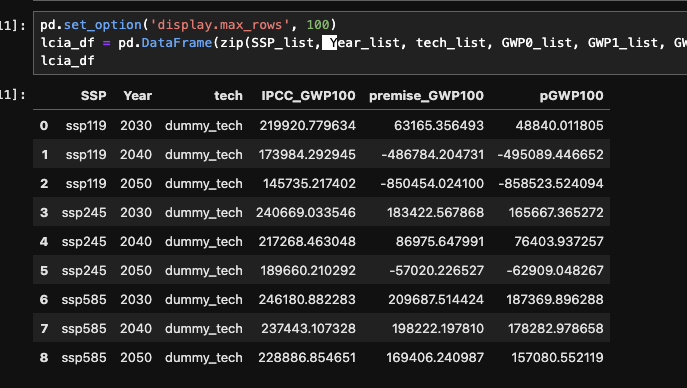

In [16]:
icev_f2_ds = get_plcia_ds(d1)
icev_f2_ds

<xarray.Dataset>
Dimensions:          (SSP: 3, v_module: 1, v_year: 3, tech_list: 1,
                      Impact_category: 3)
Coordinates:
  * SSP              (SSP) object 'ssp119' 'ssp245' 'ssp585'
  * v_module         (v_module) object 'F2_fuel_d'
  * v_year           (v_year) int64 2030 2040 2050
  * tech_list        (tech_list) object 'dummy_tech'
  * Impact_category  (Impact_category) object 'IPCC2021_default' ... 'premise...
Data variables:
    value            (SSP, v_module, v_year, tech_list, Impact_category) float64 ...

In [17]:
icev_f2_ds.to_netcdf('pGWP_module_output/F2_ICEVdGT_pGWP100.nc')

In [20]:
d1.to_excel('pGWP_module_output/excel_output/F2_ICEVdGT_pGWP100.xlsx' )
d2.to_excel('pGWP_module_output/excel_output/F2_ICEVdGT_pGWP100_annual.xlsx' )